# A-Training

In [1]:
import torch
import random
import numpy as np
import os
from tensorboardX import SummaryWriter  #tensorboardX is a TensorBoard tool for PyTorch

from TD3 import TD3
from spacecraft_flex_ft_obs_noeta_env_MRP import FlexibleSpacecraft
import flex_utils
from flex_utils import ReplayBuffer, plot_omega, plot_p, plot_Tr, plot_eta

%load_ext autoreload
%autoreload 2

### Check CUDA

In [2]:
# device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
# print(f'rolling on {torch.cuda.get_device_name(torch.cuda.current_device())}')

print(f"CUDA available: {torch.cuda.is_available()}")

# Check GPU count
if torch.cuda.is_available():
    gpu_count = torch.cuda.device_count()
    print(f"GPU count: {gpu_count}")
    
    # View each GPU info
    for i in range(gpu_count):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"GPU {i} memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.2f} GB")

if torch.cuda.is_available():
    # Set which GPU to use (e.g., GPU 0)
    torch.cuda.set_device(0)  # Select which GPU
    device = torch.device("cuda:0")
    print(f"UsingGPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("UsingCPU")

CUDA available: True
GPU count: 1
GPU 0: NVIDIA GeForce RTX 3060
GPU 0 memory: 12.00 GB
UsingGPU: NVIDIA GeForce RTX 3060


### Hyperparameters

In [ ]:
# device = torch.device("cpu")
date = '260105'
num_train = "1"   # Saved training number
save_path = './saved_model_td3/'+date+'/taining_num_'+num_train    # Model save path
logpath = './logs/'+date+'/train_num_'+num_train
writer = SummaryWriter(logpath)
os.makedirs(save_path, exist_ok=True)                       # exist_ok=True: do nothing if directory already exists
os.makedirs(logpath, exist_ok=True)

# Hyperparameters setup
actor_lr = 3e-4
critic_lr = 3e-4
num_episodes = 20000
gamma = 0.99
tau = 0.01  # Soft update param, range 0~1, tau=1 means full copy to target networks
buffer_size = 1000000
minimal_size = 1000
batch_size = 250
exploration_noise = 0.1 # Gaussian noise std dev
policy_noise = 0.2
noise_clip = 0.5
env_time = 200   # Episode duration: each step = 1s, 100 steps total per episode
dt = 1
delay = 3

# Learning rate decay: after every 10000 episodes, actor LR decays by factor of 1 (1 = no decay)
lr_step_size = 10000 
lr_gamma = 1

random.seed(2)
np.random.seed(2)
torch.manual_seed(2)

env = FlexibleSpacecraft(env_time, dt, use_disturbance=True)
state = env.reset()

replay_buffer = ReplayBuffer(buffer_size)
state_dim = state.shape[0]
action_dim = env.Tr_sol.shape[0]
action_bound = env.umax
# Actor input = state + state-reference error, so input dim = 2 * state_dim
agent = TD3(state_dim, action_dim, action_bound, policy_noise, noise_clip, actor_lr, critic_lr, tau, gamma, device, delay, lr_step_size, lr_gamma)

### Load Pretrained Model

In [4]:
# date_p = '251113'
# num_train_p = "1"  # Choose which Training to load, uncomment
# load_path_p = './saved_model_td3/'+date_p+'/taining_num_'+num_train_p
# agent.load_model(load_path_p)
# replay_buffer.load(load_path_p)

### Train Model and Save. Skip this section and run the next if training is not needed.  
1229 #1Training took1812min state out = true q, omega, observed eta, psi  
0101 #1 Training: state out = true q, observed omega, eta, psi 

In [5]:
return_list, return_list_elite, save_path_elite = flex_utils.train_off_policy_agent_td3(env, agent, num_episodes, replay_buffer, minimal_size, batch_size, writer, exploration_noise, save_path)

Iteration 0:   0%|          | 5/2000 [00:20<2:16:41,  4.11s/it, episode=5, return=-7526.497]d:\Software\anaconda3\envs\reinf\Lib\site-packages\torch\optim\lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
Iteration 9: 100%|██████████| 2000/2000 [2:57:33<00:00,  5.33s/it, episode=20000, return=14691.111]  


In [6]:
agent.save_model(save_path)         # Save model final training state
replay_buffer.save(save_path)       # Save buffer data

ReplayBuffer saved to ./saved_model_td3/260105/taining_num_1\replay_buffer.pkl


### Load Saved Model

In [7]:
# load_path = './saved_model_td3/'+date+'/taining_num_'+num_train
# agent.load_model_cpu(load_path)

### Load Elite Model

In [8]:
#save_path_elite = os.path.join(save_path, f'elite_{int(10580)}')
agent.load_model_cpu(save_path_elite)

### Test with Loaded Agent

### Scenario1: Baseline Attitude Reorientation

In [9]:
mode = 'Scenario1'
episode_return = 0
env_test = FlexibleSpacecraft(200, 1)
state = env_test.reset(mode)
done = False
while not done:
    action = agent.take_action(state)
    env_test.Tr_sol = np.column_stack((env_test.Tr_sol, action))
    next_state, reward, done, _ = env_test.step(action)
    state = next_state
    episode_return += reward

print(f'reward for this episode: {episode_return}')
plot_p(env_test.t_sol, env_test.X_sol)
plot_eta(env_test.t_sol, env_test.X_sol)
plot_omega(env_test.t_sol, env_test.X_sol)
plot_Tr(env_test.t_sol, env_test.Tr_sol)



reward for this episode: 17555.94963617028


In [10]:
# Save training curves
np.save(os.path.join(save_path, 'return_list.npy'), return_list)
np.save(os.path.join(save_path, 'return_list_elite.npy'), return_list_elite)

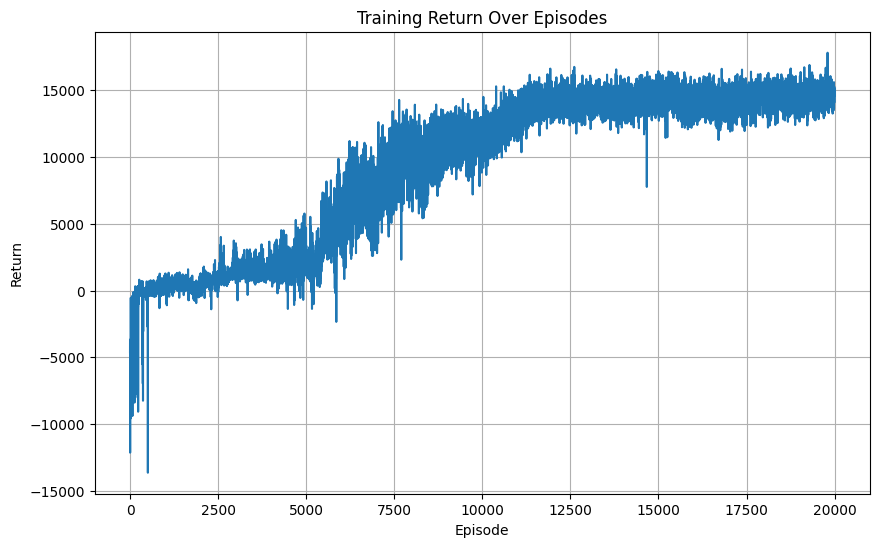

In [11]:
# Visualize training curves
import matplotlib.pyplot as plt


# Read data
return_list = np.load(os.path.join(save_path, 'return_list.npy'))

# Plot reward curve
plt.figure(figsize=(10, 6))
plt.plot(return_list)
plt.xlabel('Episode')
plt.ylabel('Return')
plt.title('Training Return Over Episodes')
plt.grid(True)
plt.show()